In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('Biometrics Data of Silver Oak.csv') #import the csv file and put it in a dataframe

FileNotFoundError: [Errno 2] No such file or directory: 'Biometrics Data of Silver Oak.csv'

In [ ]:
#check the first 5 rows to see if the dataset loads
(df.head())

,StemID,Log,Part,Layer,Leght_m,Dai_cm,Ww_kg,Dw_kg,%Moisture,Dw,...,LogVolume_m3,DwToWwRatio,DiameterClass,MoistureClass,IsOutlier,Altitude_m,Slope_deg,SoilType,Exposure,ReplicateID
0,SO0201,1,Stem,D0,0.0,10.60,0.610,0.327,86.544343,0.327,...,0.000000,0.536066,Medium,Medium,False,825.0,14.0,Sandy,West-facing,3.0
1,SO0201,1,Stem,D1,30.0,9.90,0.280,0.148,89.189189,0.148,...,0.002309,0.528571,Small,Medium,False,735.2,9.2,Clay,West-facing,2.0
2,SO0201,1,Stem,D2,60.0,9.50,0.221,0.113,95.575221,0.113,...,0.004253,0.511312,Small,High,False,857.5,11.3,Loam,East-facing,3.0
3,SO0201,2,Stem,D3,70.0,8.55,0.155,0.080,93.750000,0.080,...,0.004019,0.516129,Small,High,False,785.0,16.0,Clay,South-facing,2.0
4,SO0201,2,Stem,D4,100.0,8.13,0.138,0.071,94.366197,0.071,...,0.005191,0.514493,Small,High,False,786.2,16.0,Sandy,West-facing,2.0


In [ ]:
#columns Dai_cm and Leght_m are pronounced incorrectly, they should be Diameter_cm and Length_m
df = df.rename(columns={"Dai_cm": "Diameter_cm","Leght_m": "Length_m"})

In [ ]:
#inspect the data, by checking the structure or shape and data types
print("The shape of the dataset is ", df.shape)

The shape of the dataset is  (2030, 25)


In [ ]:
print("The datatypes of the dataset is\n", df.dtypes)

The datatypes of the dataset is
 StemID              object
Log                 object
Part                object
Layer               object
Length_m           float64
Diameter_cm        float64
Ww_kg              float64
Dw_kg              float64
%Moisture          float64
Dw                 float64
TreeGroup           object
Region              object
HealthStatus        object
MeasurementDate     object
TechnicianID        object
LogVolume_m3       float64
DwToWwRatio        float64
DiameterClass       object
MoistureClass       object
IsOutlier             bool
Altitude_m         float64
Slope_deg          float64
SoilType            object
Exposure            object
ReplicateID        float64
dtype: object


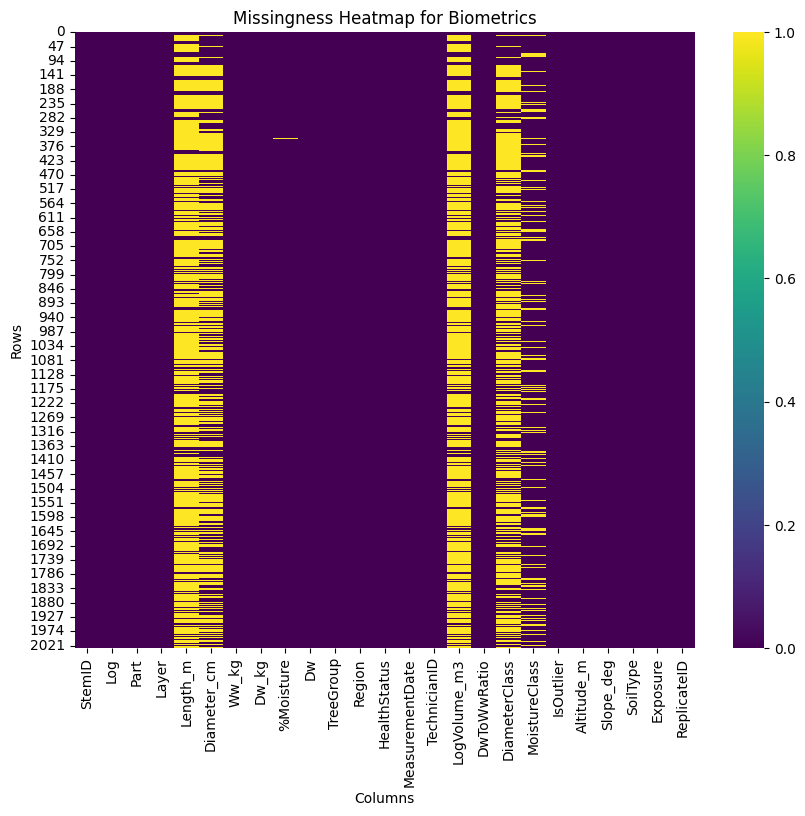

In [ ]:
#now checking if there is any missing data before data cleaning
plt.figure(figsize=(10, 8))
sns.heatmap(df.isna(),  cmap="viridis")
plt.title("Missingness Heatmap for Biometrics")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

In [ ]:
#now for checking valid values, making sure there is no negatives and no out of range values
print(df.describe())

          Length_m  Diameter_cm        Ww_kg        Dw_kg    %Moisture  \
count   411.000000   829.000000  2030.000000  2030.000000  2029.000000   
mean    350.892513     9.918720     0.387988     0.215564    53.849207   
std     381.027738     9.512478     0.684435     0.401073    26.909835   
min       0.000000     1.270077     0.002794     0.001671   -78.260870   
25%      98.331835     3.410531     0.043052     0.024077    41.611476   
50%     210.000000     6.816849     0.117454     0.062570    47.106696   
75%     502.810181    13.603519     0.352886     0.203603    54.613786   
max    1573.926373    51.338439     4.297103     2.739303   784.042553   

                Dw  LogVolume_m3  DwToWwRatio   Altitude_m    Slope_deg  \
count  2030.000000    399.000000  2030.000000  2030.000000  2030.000000   
mean      0.217396      0.050237     0.554343   799.426070    14.968753   
std       0.402941      0.080424     0.119325    49.866122     5.050677   
min       0.001695      0.000000 

In [ ]:
#first data validation, since the MeasurementDate column had a wrong data type, it should be fixed
print(f"Data type before change:{df["MeasurementDate"].dtypes}")
df["MeasurementDate"] = pd.to_datetime(df["MeasurementDate"], errors="coerce")
#ensure that the MeasurementDate datatype has changed
print(f"Data type after change:{df["MeasurementDate"].dtypes}")

Data type before change:object
Data type after change:datetime64[ns]


In [ ]:
#the %Moisture column has a max of ~784 and a min of ~-78, so it must be validated
#percentages are bounded by definition, there is no definition given for the scale so 100% is 
#treated as the maximum percentage
df.loc[(df["%Moisture"] < 0) | (df["%Moisture"] > 100), "%Moisture"] = np.nan
print("new missing values",df["%Moisture"].isna().sum())

new missing values 74


In [ ]:
#for safety practice, ensure every column with a
#numerical datatype is valid using physical constraints:
df.loc[df["Length_m"] <= 0, "Length_m"] = np.nan
df.loc[df["Diameter_cm"] <= 0, "Diameter_cm"] = np.nan
df.loc[df["Ww_kg"] <= 0, "Ww_kg"] = np.nan
df.loc[df["Dw_kg"] <= 0, "Dw_kg"] = np.nan
df.loc[df["LogVolume_m3"] <= 0, "LogVolume_m3"] = np.nan
df.loc[df["Altitude_m"] <= 0, "Altitude_m"] = np.nan
df.loc[df["Slope_deg"] < 0, "Slope_deg"] = np.nan

In [ ]:
#since we know every categorical column, we now see the unique values put every categorical column in a list
Categorical_Columns = ["StemID","Log", "Part", "Layer", "TreeGroup", "Region","HealthStatus",
                       "TechnicianID","DiameterClass", "MoistureClass", "SoilType", "Exposure"]
#loop through the list to print every unique value of it
for Column in Categorical_Columns:
    print(f"Unique Values in {Column} column:",end=" ")
    print(df[Column].unique(),end = "\n\n")

Unique Values in StemID column: ['SO0201' 'SO0202' 'SO0301' 'SO0302' 'SO04' 'SO05' 'SO06' 'SO07' 'SO08'
 'SO09']

Unique Values in Log column: ['1' '2' '3' '4' '5' 'B' 'L' 'PR' 'SR1' 'SR2' 'SR3' '6' '7' 'MR' '8' '9'
 'M-B-1' 'M-B-2' 'M-M' 'M-S' 'S-B' 'S-M' 'S-S' 'TR' '10' '11' 'M-B'
 'M-B-3' 'M-M-1' 'M-M-2' 'M-M-3' 'SR4' '12' '13' '14' '15' 'M-B-4' 'M-B-5'
 'M-B-6' 'M-B-7' 'M-B-8' 'M-B-9' 'M-M-4' 'M-M-5' 'M-S-1' 'M-S-2' 'M-S-3'
 'M-S-4' 'M-S-5' 'M-S-6' 'M-S-7' 'M-S-8' 'M-S-9' 'M-S-10' 'S-B-1' 'S-B-2'
 'S-B-3' 'S-M-1' 'S-M-2' 'S-M-3' 'S-S-1' 'S-S-2' 'S-S-3']

Unique Values in Part column: ['Stem' 'Brance' 'Leaf' 'Root']

Unique Values in Layer column: ['D0' 'D1' 'D2' 'D3' 'D4' 'D5' 'D6' 'D7' 'D8' 'D9' 'B1' 'B2' 'B3' 'L1'
 'D10' 'D11' 'D12' 'D13' 'D14' 'D30' 'D100' 'D130' 'D300' 'D500' 'D700'
 'D900' 'D1100' 'B1-1' 'B1-2' 'B1-3' 'B2-1' 'B2-2' 'B2-3' 'L2' 'L3'
 'D1300' 'D1500' 'B1-4' 'B1-5' 'B3-1' 'B3-2' 'B2-4' 'B3-3' 'B3-4' 'D0-1'
 'D0-2' 'D30-1' 'D30-2' 'D100-1' 'D100-2' 'D1700' 'D130-1

In [ ]:
#the unique "keys" in the dataset
UniqueKeys = ["StemID", "Layer","Log", "Part", "ReplicateID"]

#checking for the duplicates
DuplicateMask = df.duplicated(subset=UniqueKeys, keep="first")
print("duplicated rows number - ", DuplicateMask.sum())

#drop the duplicates
df = df.drop_duplicates(subset=UniqueKeys, keep="first")
print("Shape of the dataset after removal - ", df.shape)

duplicated rows number -  34
Shape of the dataset after removal -  (1996, 25)


In [ ]:
#for every part in the Layer column, we check every unique value
#list of all unique parts
unique_parts = df["Part"].unique()
#loop through each unique Part to see which Layers belong in it
for part in unique_parts:
    print("Part:", part)
    #filter rows for this specific Part then grab the unique Layer names like 2d arrays
    print(df[df["Part"] == part]["Layer"].unique(),end="\n\n") 

Part: Stem
['D0' 'D1' 'D2' 'D3' 'D4' 'D5' 'D6' 'D7' 'D8' 'D9' 'D10' 'D11' 'D12' 'D13'
 'D14' 'D30' 'D100' 'D130' 'D300' 'D500' 'D700' 'D900' 'D1100' 'D1300'
 'D1500' 'D0-1' 'D0-2' 'D30-1' 'D30-2' 'D100-1' 'D100-2' 'D1700' 'D130-1'
 'D130-2' 'D700-1' 'D700-2' 'D900-1' 'D900-2' 'D1100-1']

Part: Brance
['B1' 'B2' 'B3' 'B1-1' 'B1-2' 'B1-3' 'B2-1' 'B2-2' 'B2-3' 'B1-4' 'B1-5'
 'B3-1' 'B3-2' 'B2-4' 'B3-3' 'B3-4' 'B4' 'B5' 'B6' 'B7' 'B8' 'B9' 'B10']

Part: Leaf
['L1' 'L2' 'L3']

Part: Root
['D1' 'D2' 'D3' 'D4']



In [ ]:
#in the metadata, it is stated that log is a number so we check log's unique values
print("Unique values of Log before removal of non-stem values: \n",df['Log'].unique(),end="\n\n")
#we check log's unique values after making a temporary dataframe, where every part that is not "Stem" is removed
temp_df = df[df["Part"].isin(["Stem"])]
print("Unique values of Log after removal of non-stem values: \n",temp_df['Log'].unique())
#Non "Stem" records introduce invalid values into the Log column so
#Log should only be interpreted and analysed for Stem samples.

Unique values of Log before removal of non-stem values: 
 ['1' '2' '3' '4' '5' 'B' 'L' 'PR' 'SR1' 'SR2' 'SR3' '6' '7' 'MR' '8' '9'
 'M-B-1' 'M-B-2' 'M-M' 'M-S' 'S-B' 'S-M' 'S-S' 'TR' '10' '11' 'M-B'
 'M-B-3' 'M-M-1' 'M-M-2' 'M-M-3' 'SR4' '12' '13' '14' '15' 'M-B-4' 'M-B-5'
 'M-B-6' 'M-B-7' 'M-B-8' 'M-B-9' 'M-M-4' 'M-M-5' 'M-S-1' 'M-S-2' 'M-S-3'
 'M-S-4' 'M-S-5' 'M-S-6' 'M-S-7' 'M-S-8' 'M-S-9' 'M-S-10' 'S-B-1' 'S-B-2'
 'S-B-3' 'S-M-1' 'S-M-2' 'S-M-3' 'S-S-1' 'S-S-2' 'S-S-3']

Unique values of Log after removal of non-stem values: 
 ['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15']


In [ ]:
#checking the non-null rows of Length_m, Diameter_cm, and LogVolume_m3
#before and after removing the non-stem parts TEMPORARILY, since the data is about the stem measurements
print("Number of rows before removal of non-stem:\n",df[["Length_m", "Diameter_cm", "LogVolume_m3"]].count())
print("out of ",df.shape[0]," rows",end = "\n\n")

#ratio of non-null row count to all rows is big

temp_df2 = df[df["Part"].isin(["Stem"])] #remove non stem parts in another dataframe

print("Number of rows after removal:\n",temp_df2[["Length_m", "Diameter_cm", "LogVolume_m3"]].count())
print("out of ",temp_df2.shape[0]," rows")

#ratio of non-null row count to all rows is small

Number of rows before removal of non-stem:
 Length_m        353
Diameter_cm     810
LogVolume_m3    344
dtype: int64
out of  1996  rows

Number of rows after removal:
 Length_m        353
Diameter_cm     467
LogVolume_m3    344
dtype: int64
out of  492  rows


In [ ]:
#all evidence show that non stem parts must be removed, hence they are removed
df = df[df["Part"] == "Stem"]
print("Rows after keeping only Stem:", df.shape[0])

Rows after keeping only Stem: 492


In [ ]:
#since all parts are stem now, the part column is useless so we drop it
df = df.drop(columns = ["Part"])

In [ ]:
#changing Log's data type
df["Log"] = pd.to_numeric(df["Log"], errors="coerce")
print("Rows that are non-numeric in Log:", df["Log"].isna().sum())
print("Log's data type:",df["Log"].dtype)

Rows that are non-numeric in Log: 0
Log's data type: int64


In [ ]:
#from the meta data, the valid layers are from D0-D7
valid_layers = ["D0","D1","D2","D3","D4","D5","D6","D7"]
# make a new column where it has only the valid layers labelled, anything else is labelled as "Other"
df["LayerGroup"] = df["Layer"].where(df["Layer"].isin(valid_layers), "Other") 

In [ ]:
#for the IsOutlier column, it should be validated if it shows the real outliers or not
#calculate the interquartile range
Q1 = df['DwToWwRatio'].quantile(0.25)
Q3 = df['DwToWwRatio'].quantile(0.75)
IQR = Q3 - Q1

#define the boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#determine the real outliers 
real_outliers = (df['DwToWwRatio'] < lower_bound) | (df['DwToWwRatio'] > upper_bound)

#check how many rows are incorrectly flagged before overwriting them
mismatch = df['IsOutlier'] != real_outliers
wrong_count = mismatch.sum()
print("The number of fake incorrectly flagged values is", wrong_count)

#correct the IsOutlier values
df['IsOutlier'] = real_outliers

The number of fake incorrectly flagged values is 36


In [ ]:
#dry weight shouldnt be more than wet weight 
impossible_ratio = df["Dw_kg"] > df["Ww_kg"]
df.loc[impossible_ratio, ["Dw_kg", "Ww_kg"]] = np.nan
#print the rows that have the impossible ratio before
print("rows with an impossible ratio before:", impossible_ratio.sum())
#fill the weights with the median as it is only one value
df["Ww_kg"] = df["Ww_kg"].fillna(df["Ww_kg"].median())
df["Dw_kg"] = df["Dw_kg"].fillna(df["Dw_kg"].median())
#recalculate ratio to fill in the missing row
df["DwToWwRatio"] = df["Dw_kg"] / df["Ww_kg"]
impossible_ratio = df["Dw_kg"] > df["Ww_kg"]
#print the rows that have the impossible ratio after
print("rows with an impossible ratio after:", impossible_ratio.sum())

rows with an impossible ratio before: 1
rows with an impossible ratio after: 0


In [ ]:
#a list of categorical columns to check the relationship of the stats of each column with the moisture%
CategoricalColumns = ["DiameterClass", "Exposure", "SoilType", "HealthStatus", "TreeGroup", "Region"]

#loop through each category and print the summary for each
for column in CategoricalColumns:    
    #group by each column to see each column's mean
    summary = df.groupby(column)["%Moisture"].agg(["count", "mean", "median", "std"])
    print(f"Moisture Summary for {column}\n {summary}",end="\n\n")

Moisture Summary for DiameterClass
                count       mean     median        std
DiameterClass                                        
Large             52  55.253099  49.174228  15.249619
Medium            84  52.543601  47.792056  19.387524
Small            135  58.502849  51.658095  16.804556
Very Small        53  55.914228  50.605940  16.889891

Moisture Summary for Exposure
               count       mean     median        std
Exposure                                            
East-facing      92  54.814700  49.608957  16.582806
North-facing    101  56.849006  50.314075  16.471346
South-facing    128  55.021126  49.713964  16.050157
West-facing     133  53.466542  48.604533  18.345270

Moisture Summary for SoilType
           count       mean     median        std
SoilType                                        
Clay        171  54.736765  49.732715  15.019202
Loam        153  55.623556  50.708524  17.044345
Sandy       130  54.369731  49.230694  19.154208

Moisture Sum

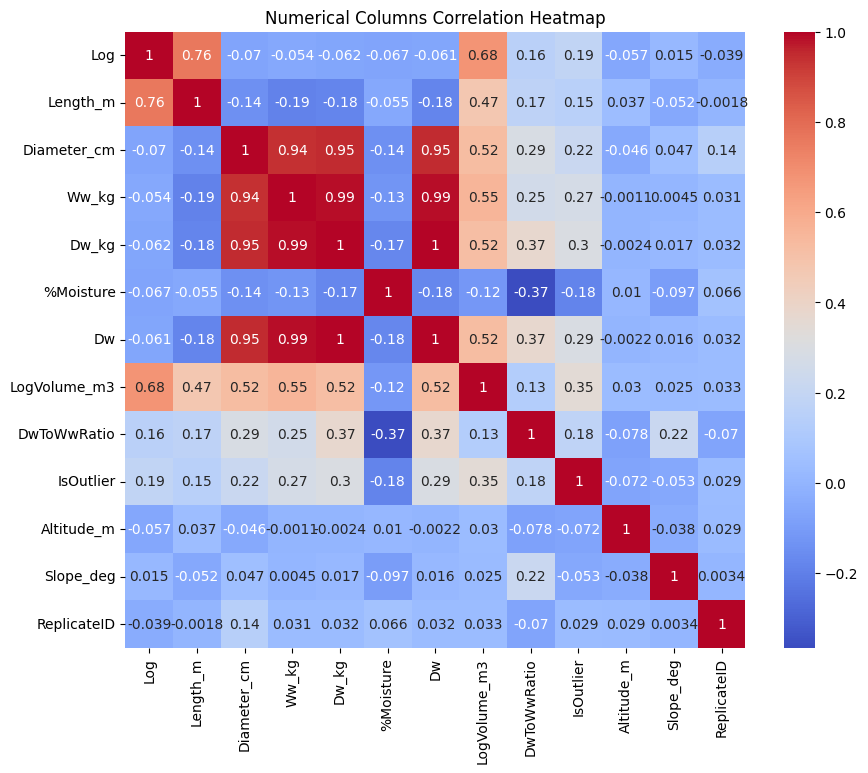

In [ ]:
#plot a heatmap to detemine the correation of %moisture to every other numerical column
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True)
plt.title("Numerical Columns Correlation Heatmap")
plt.show()

In [ ]:
#check the missing moisture percentage values' count before filling the missing values
print("Missing %Moisture before:", df["%Moisture"].isna().sum())
#fill the missing moisture values using the global median
#since there is no correlation between it and any categorical or numerical column
df["%Moisture"] = df["%Moisture"].fillna(df["%Moisture"].median())
#check the missing moisture percentage values' count after filling the missing values
print("Missing %Moisture after:", df["%Moisture"].isna().sum())

Missing %Moisture before: 38
Missing %Moisture after: 0


In [ ]:
#before filling in the missing values of the diameter, length, and volume
#we should first check if the volume is actually derived and caluculated using the cylinder formula
#check by making a data frame containing only using the rows where the three values exist
vol_df = df[ df["LogVolume_m3"].notna() & df["Diameter_cm"].notna() & df["Length_m"].notna()].copy()

#making a column that has the cylinder formula volume values
vol_df["CylinderVolume"] = (np.pi *((vol_df["Diameter_cm"] / 100) / 2) ** 2 * vol_df["Length_m"])

#check stats for original log volume
print("Recorded LogVolume_m3:")
print(vol_df["LogVolume_m3"].describe())

Recorded LogVolume_m3:
count    344.000000
mean       0.057081
std        0.083505
min        0.001276
25%        0.006187
50%        0.022004
75%        0.069809
max        0.393966
Name: LogVolume_m3, dtype: float64


In [ ]:
#checking stats for cylinder formula volumes
print("Volume found using cylinder formula")
print(vol_df["CylinderVolume"].describe())

Volume found using cylinder formula
count    344.000000
mean       5.722328
std        8.353376
min        0.127588
25%        0.616652
50%        2.200548
75%        7.044317
max       40.741454
Name: CylinderVolume, dtype: float64


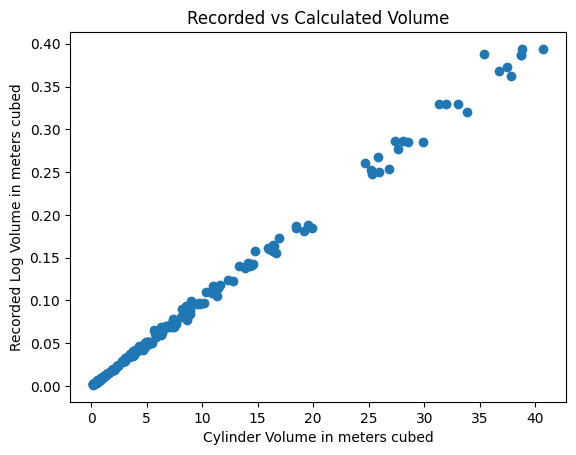

In [ ]:
#check the values using a scatter plot
plt.scatter(vol_df["CylinderVolume"], vol_df["LogVolume_m3"])
plt.xlabel("Cylinder Volume in meters cubed")
plt.ylabel("Recorded Log Volume in meters cubed")
plt.title("Recorded vs Calculated Volume")
plt.show()

In [ ]:
#the cylinder formula gave volumes ~100× larger than recorded values since both the formula itself
#and the diameter values are correct, the mismatch should have come from the length variable so
#to fix this the length is rescaled to keep the units consistent
df["Length_m"] = df["Length_m"] / 100

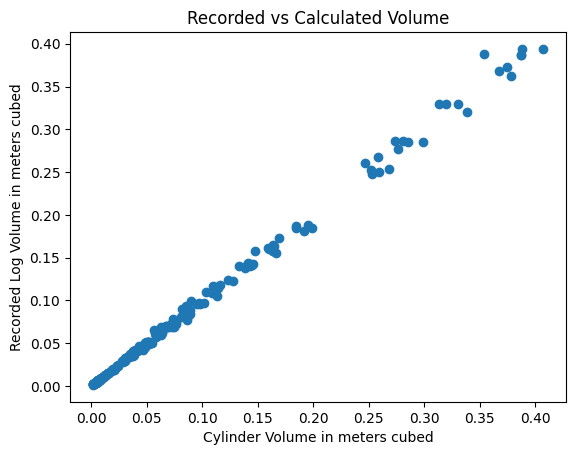

In [ ]:
#to verify that the values are now consistent, we should redo the same comparision 
vol_df = df[ df["LogVolume_m3"].notna() & df["Diameter_cm"].notna() & df["Length_m"].notna()].copy()
vol_df["CylinderVolume"] = (np.pi *((vol_df["Diameter_cm"] / 100) / 2) ** 2 * vol_df["Length_m"])

#now plot a scatter plot to see how much they correlate
plt.scatter(vol_df["CylinderVolume"], vol_df["LogVolume_m3"])
plt.xlabel("Cylinder Volume in meters cubed")
plt.ylabel("Recorded Log Volume in meters cubed")
plt.title("Recorded vs Calculated Volume")
plt.show()

In [ ]:
#to verify that the values are now consistent, we should redo the same comparision 
vol2_df = df[ df["LogVolume_m3"].notna() & df["Diameter_cm"].notna() & df["Length_m"].notna()].copy()
#but this time, using the cylinder volume formula as it is stated in the metadata that it was used
vol2_df["CylinderVolume"] = (np.pi *((vol2_df["Diameter_cm"] / 100) / 2) ** 2 * vol2_df["Length_m"])

#check stats for original log volume
print("Recorded LogVolume_m3:")
print(vol2_df["LogVolume_m3"].describe())

Recorded LogVolume_m3:
count    344.000000
mean       0.057081
std        0.083505
min        0.001276
25%        0.006187
50%        0.022004
75%        0.069809
max        0.393966
Name: LogVolume_m3, dtype: float64


In [ ]:
#checking stats again for cylinder formula volumes verification
print("Volume found using cylinder formula")
print(vol2_df["CylinderVolume"].describe())

Volume found using cylinder formula
count    344.000000
mean       0.057223
std        0.083534
min        0.001276
25%        0.006167
50%        0.022005
75%        0.070443
max        0.407415
Name: CylinderVolume, dtype: float64


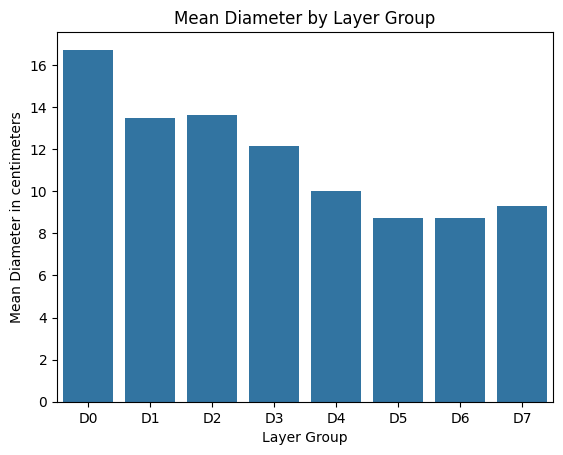

In [ ]:
#bar chart for the Diameter_cm column by grouping every valid layer except the Other
diameter_by_layer = (df[df["LayerGroup"] != "Other"].groupby("LayerGroup")["Diameter_cm"].mean().sort_index())
sns.barplot(x="LayerGroup", y="Diameter_cm",data= diameter_by_layer.reset_index())
plt.title("Mean Diameter by Layer Group")
plt.xlabel("Layer Group")
plt.ylabel("Mean Diameter in centimeters")
plt.show()

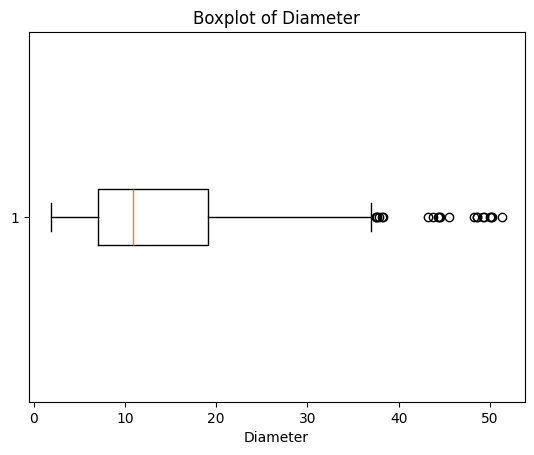

In [ ]:
#boxplot to see the distribution and skewness and outliers in Diameter_cm
plt.boxplot(df["Diameter_cm"].dropna(), vert = False) #vert = False to make it horizantal
plt.xlabel("Diameter")
plt.title("Boxplot of Diameter")
plt.show()

In [ ]:
#check the missing diameter values' count before filling the missing values
print("Missing Diameter_cm values before:", df["Diameter_cm"].isna().sum())

#use median grouped by layer group to find the median diameter for each valid layer
Diameter_layer_median = (df[df["LayerGroup"] != "Other"].groupby("LayerGroup")["Diameter_cm"].median())

#fill the missing values using the map of the layer medians we just calculated
Diameter_mask = df["Diameter_cm"].isna() & (df["LayerGroup"] != "Other")
df.loc[Diameter_mask, "Diameter_cm"] = df.loc[Diameter_mask, "LayerGroup"].map(Diameter_layer_median)

#global median fill for remaining missing values
df["Diameter_cm"] = df["Diameter_cm"].fillna(df["Diameter_cm"].median())

#check the missing diameter values' count after filling the missing values
print("Missing Diameter_cm after:", df["Diameter_cm"].isna().sum())

Missing Diameter_cm values before: 25
Missing Diameter_cm after: 0


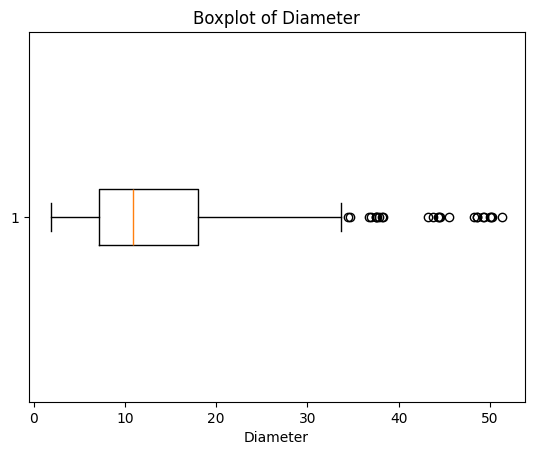

In [ ]:
#boxplot to see the distribution and skewness and outliers in Diameter_cm after filling the missing values
plt.boxplot(df["Diameter_cm"].dropna(), vert = False) #vert = False to make it horizantal
plt.xlabel("Diameter")
plt.title("Boxplot of Diameter")
plt.show()

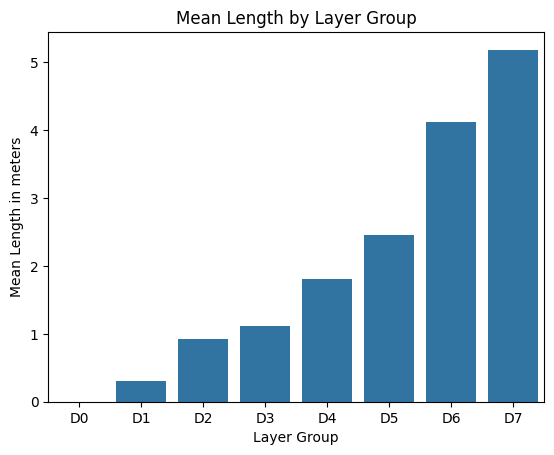

In [ ]:
#bar chart for the length_m column by grouping every valid layer except the Other
length_by_layer = (df[df["LayerGroup"] != "Other"].groupby("LayerGroup")["Length_m"].mean().sort_index())
sns.barplot(x="LayerGroup", y="Length_m",data=length_by_layer.reset_index())
plt.title("Mean Length by Layer Group")
plt.xlabel("Layer Group")
plt.ylabel("Mean Length in meters")
plt.show()

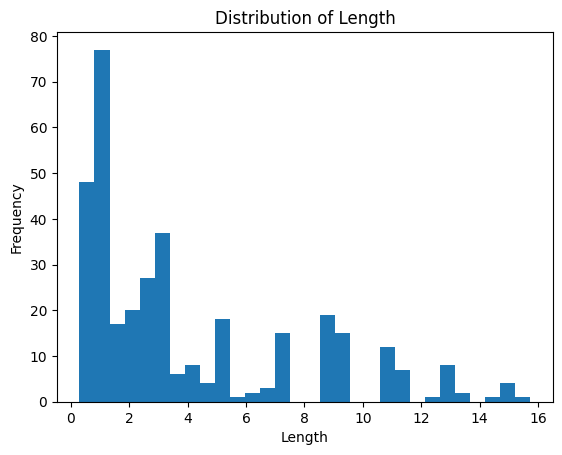

In [ ]:
#plot a histogram to chekc the length's skewness
plt.hist(df["Length_m"].dropna(), bins=30)
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.title("Distribution of Length")
plt.show()

In [ ]:
#print the missing values before
print("Missing Length_m values before:", df["Length_m"].isna().sum())

#use median grouped by layer group to find the median length for each valid layer
length_layer_median = (df[df["LayerGroup"] != "Other"].groupby("LayerGroup")["Length_m"].median())

#fill the missing values using the map of the layer medians we just calculated
Length_mask = df["Length_m"].isna() & (df["LayerGroup"] != "Other")
df.loc[Length_mask, "Length_m"] = df.loc[Length_mask, "LayerGroup"].map(length_layer_median)

#global median fill for remaining missing values
df["Length_m"] = df["Length_m"].fillna(df["Length_m"].median())
#making the length  for layer D0 be 0
df.loc[df["LayerGroup"] == "D0", "Length_m"] = 0
#print missing values after filling
print("Missing Length_m values after:", df["Length_m"].isna().sum())

Missing Length_m values before: 139
Missing Length_m values after: 0


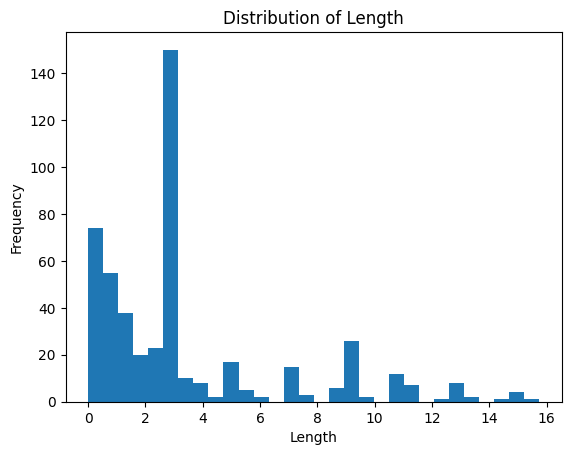

In [ ]:
#plot a histogram to chekc the length's skewness after filling the missing values
plt.hist(df["Length_m"].dropna(), bins=30)
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.title("Distribution of Length")
plt.show()

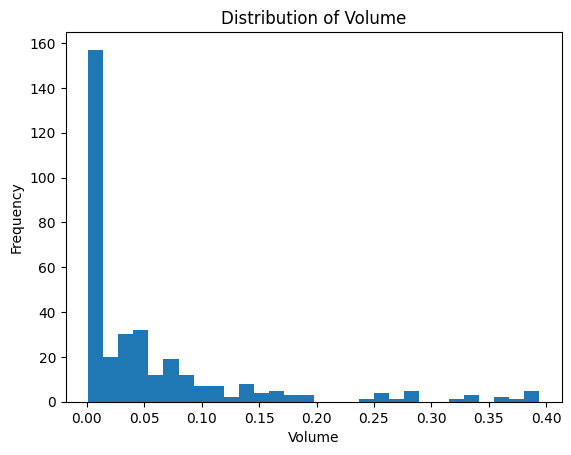

In [ ]:
#plot a histogram to chekc the volumes's skewness before filling the missing values
plt.hist(df["LogVolume_m3"].dropna(), bins=30)
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.title("Distribution of Volume")
plt.show()

In [ ]:
#now fill the missing volume values, do a mask first
missing_volume = df["LogVolume_m3"].isna()
#print the missing values before
print("Missing LogVolume_m3 values before:", df["LogVolume_m3"].isna().sum())
#use the formula to fill in the missing values
df.loc[missing_volume, "LogVolume_m3"] = (np.pi * ((df.loc[missing_volume, "Diameter_cm"] / 100) / 2) ** 2 * df.loc[missing_volume, "Length_m"])
#making every value of the volume for layer D0 equal to 0
df.loc[df["LayerGroup"] == "D0", "LogVolume_m3"] = 0
#print the missing values after
print("Missing LogVolume_m3 values after:", df["LogVolume_m3"].isna().sum())

Missing LogVolume_m3 values before: 148
Missing LogVolume_m3 values after: 0


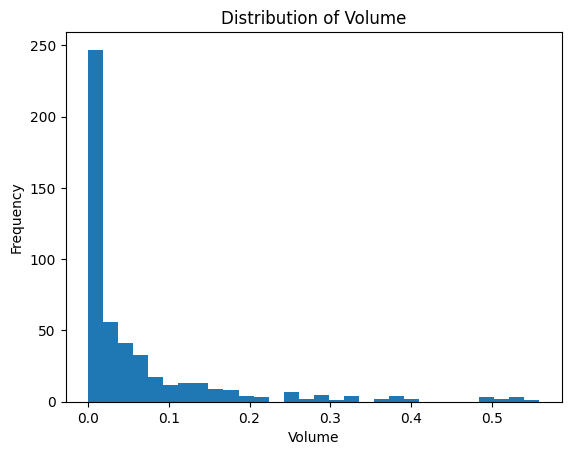

In [ ]:
#plot a histogram to chekc the volumes's skewness after filling the missing values
plt.hist(df["LogVolume_m3"].dropna(), bins=30)
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.title("Distribution of Volume")
plt.show()

In [ ]:
#check the missing values
print(df[["DiameterClass", "MoistureClass"]].isna().sum())

DiameterClass    137
MoistureClass    164
dtype: int64


In [ ]:
#we check every class unique value
print("Diameter class unique values:\n",df["DiameterClass"].unique(),end="\n\n")
print("Moisture class unique values:\n",df["MoistureClass"].unique(),end="\n\n")

Diameter class unique values:
 ['Medium' 'Small' 'Very Small' nan 'Large']

Moisture class unique values:
 ['Medium' 'High' nan 'Low']



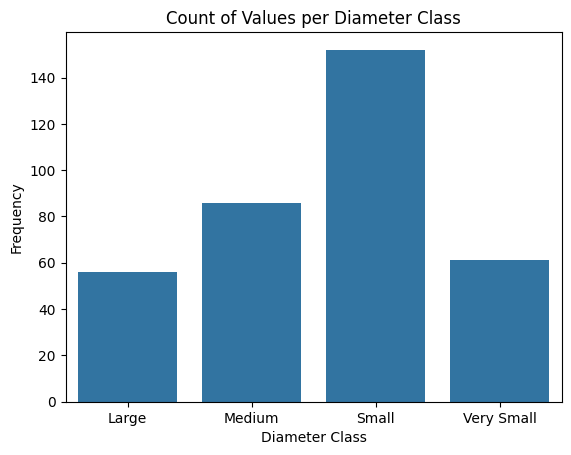

In [ ]:
#we check the number of each class in the diameter column before filling
#using a bar chart for DiameterClass
#after checking the counts we sort them by index like Very Small to Large and reset index for plotting
diameter_counts = (df["DiameterClass"].value_counts().sort_index().reset_index())
diameter_counts.columns = ["DiameterClass", "Count"]
sns.barplot(x="DiameterClass", y="Count", data=diameter_counts)
plt.title("Count of Values per Diameter Class")
plt.xlabel("Diameter Class")
plt.ylabel("Frequency")
plt.show()

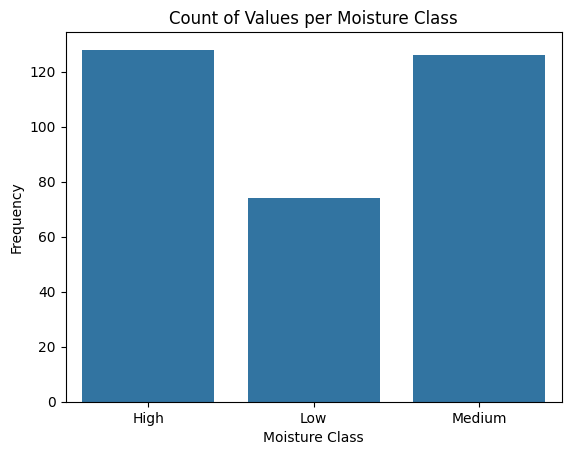

In [ ]:
#we check the number of each class in the diameter column after filling
#using a bar chart for MoistureClass
moisture_counts = (df["MoistureClass"].value_counts().sort_index().reset_index())
moisture_counts.columns = ["MoistureClass", "Count"]
sns.barplot(x="MoistureClass", y="Count", data=moisture_counts)
plt.title("Count of Values per Moisture Class")
plt.xlabel("Moisture Class")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#we use qcut to divide the values into bins of equal number of values (quantiles)
#making sure  that each class has almost the same number of values
#the missing values in moisture and diameter class are automatically filled by the
#function because the source columns Diameter_cm and %Moisture were already filled before
#so every row gets a valid class label
df["DiameterClass"] = pd.qcut(df["Diameter_cm"], q=4, labels=["Very Small", "Small", "Medium", "Large"])
df["MoistureClass"] = pd.qcut(df["%Moisture"],q=3,labels=["Low", "Medium", "High"])

In [ ]:
#check the missing values again
print(df[["DiameterClass", "MoistureClass"]].isna().sum())

DiameterClass    0
MoistureClass    0
dtype: int64


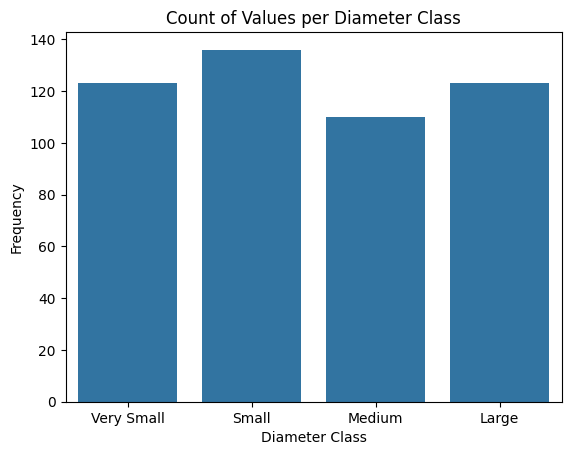

In [ ]:
#we check the number of each class in the diameter column after filling
#using a bar chart for DiameterClass
#after checking the counts we sort them by index like Very Small to Large and reset index for plotting
diameter_counts = (df["DiameterClass"].value_counts().sort_index().reset_index())
diameter_counts.columns = ["DiameterClass", "Count"]
sns.barplot(x="DiameterClass", y="Count", data=diameter_counts)
plt.title("Count of Values per Diameter Class")
plt.xlabel("Diameter Class")
plt.ylabel("Frequency")
plt.show()

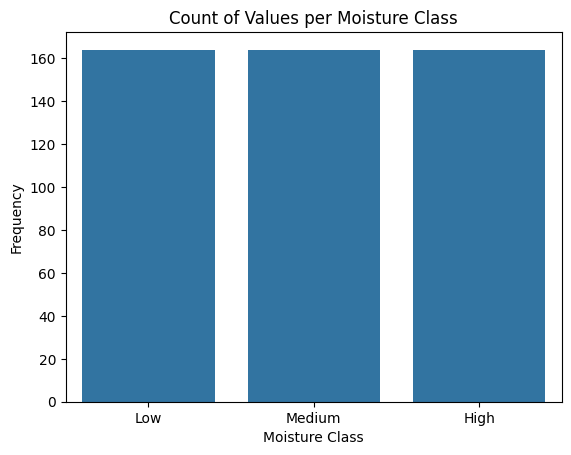

In [ ]:
#we check the number of each class in the diameter column after filling
#using a bar chart for MoistureClass
moisture_counts = (df["MoistureClass"].value_counts().sort_index().reset_index())
moisture_counts.columns = ["MoistureClass", "Count"]
sns.barplot(x="MoistureClass", y="Count", data=moisture_counts)
plt.title("Count of Values per Moisture Class")
plt.xlabel("Moisture Class")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#we check every class unique value again
print("Diameter class unique values:\n",df["DiameterClass"].unique(),end="\n\n")
print("Moisture class unique values:\n",df["MoistureClass"].unique(),end="\n\n")

Diameter class unique values:
 ['Small', 'Very Small', 'Medium', 'Large']
Categories (4, object): ['Very Small' < 'Small' < 'Medium' < 'Large']

Moisture class unique values:
 ['High', 'Medium', 'Low']
Categories (3, object): ['Low' < 'Medium' < 'High']



In [ ]:
#value_counts to check the value per class after the cleaning
print(df['DiameterClass'].value_counts(),end ="\n\n")
print(df['MoistureClass'].value_counts())

DiameterClass
Small         136
Very Small    123
Large         123
Medium        110
Name: count, dtype: int64

MoistureClass
Low       164
Medium    164
High      164
Name: count, dtype: int64


In [ ]:
#ordinal encoding where we convert the categorical values into numerical values 
#like 0, 1, 2 so they can be used in machine learning models
#using a map to keep the order accurate
diameter_map = {'Very Small': 0, 'Small': 1, 'Medium': 2, 'Large': 3}
moisture_map = {'Low': 0, 'Medium': 1, 'High': 2}

#make the new numerical columns
df['DiameterClassEncoded'] = df['DiameterClass'].map(diameter_map)
df['MoistureClassEncoded'] = df['MoistureClass'].map(moisture_map)

#check 5 random rows to see if the encode worked
print(df[['DiameterClass', 'DiameterClassEncoded', 'MoistureClass', 'MoistureClassEncoded']].sample(n=5))

     DiameterClass DiameterClassEncoded MoistureClass MoistureClassEncoded
602          Small                    1           Low                    0
1697    Very Small                    0          High                    2
636          Large                    3          High                    2
153          Small                    1          High                    2
1183         Small                    1          High                    2


In [ ]:
#one-hot encoding for SoilType as SoilType is nominal, without an order so we use one-hot encoding to avoid fake ranks

#pd.get_dummies is used to convert the SoilType column into many binary columns
#pd.get_dummies gives booleans, false, and true
df = pd.get_dummies(df, columns=["SoilType"], dtype=int) #dtype=int makes sure the values are numbers (0, 1) 

print(df.filter(like='Soil').sample(n=5))

      SoilType_Clay  SoilType_Loam  SoilType_Sandy
320               0              0               1
1954              1              0               0
1811              1              0               0
546               1              0               0
848               0              0               1


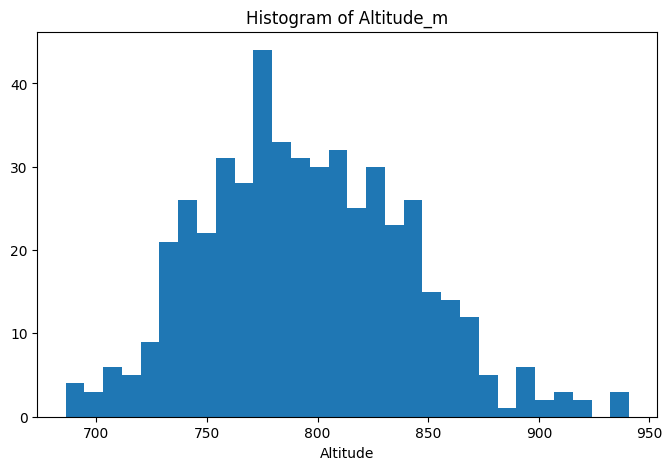

In [ ]:
#Altitude_m histogram to determine the skewness
plt.figure(figsize=(8, 5))
plt.hist(df['Altitude_m'],bins = 30)
plt.title('Histogram of Altitude_m')
plt.xlabel('Altitude')
plt.show()

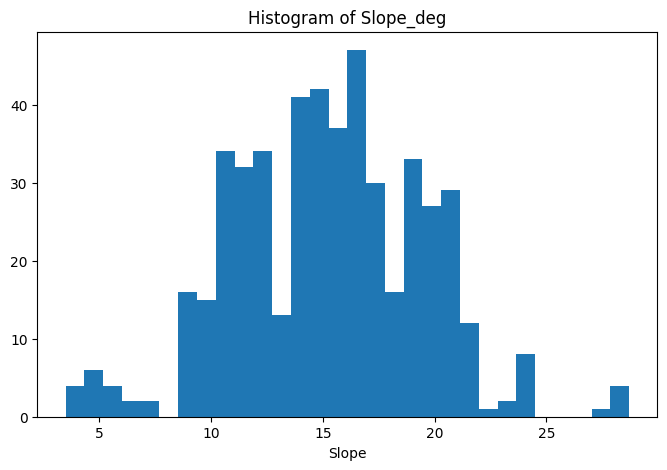

In [ ]:
#Slope_deg histogram to determine the skewness
plt.figure(figsize=(8, 5))
plt.hist(df['Slope_deg'],bins = 30)
plt.title('Histogram of Slope_deg')
plt.xlabel('Slope')
plt.show()

In [ ]:
#normalize the Altitude_m column, by making all the altitudes values between 0 and 1
df["Altitude_Norm"] = (df["Altitude_m"] - df["Altitude_m"].min()) / (df["Altitude_m"].max() - df["Altitude_m"].min())

In [ ]:
#check the difference between the two columns
print(df[['Altitude_m', 'Altitude_Norm']].describe())

       Altitude_m  Altitude_Norm
count  492.000000     492.000000
mean   795.090173       0.427871
std     46.314259       0.181826
min    686.104050       0.000000
25%    761.081502       0.294356
50%    791.715404       0.414622
75%    828.584202       0.559366
max    940.821344       1.000000


In [ ]:
#standarize the Slope_deg column
df["SlopeStandard"] = (df["Slope_deg"] - df["Slope_deg"].mean()) / df["Slope_deg"].std()

#mean should be extremely close to 0, and std should be exactly 1.
print(df[["Slope_deg", "SlopeStandard"]].describe().round(2))

       Slope_deg  SlopeStandard
count     492.00         492.00
mean       15.24          -0.00
std         4.26           1.00
min         3.49          -2.75
25%        12.07          -0.74
50%        15.31           0.02
75%        18.45           0.75
max        28.70           3.16


In [ ]:
#adding a new cross sectional area column
df["CrossSectionArea_cm2"] = df["Diameter_cm"].apply(lambda d: np.pi * (d / 2) ** 2)

In [ ]:
#doing an alititude band column to categorize elavation levels
df["AltitudeBand"] = pd.qcut(df["Altitude_m"],q=3, labels=["Low", "Medium", "High"])

In [ ]:
#check the unique values of the AltitudeBand column
df["AltitudeBand"].value_counts()

AltitudeBand
Low       164
Medium    164
High      164
Name: count, dtype: int64

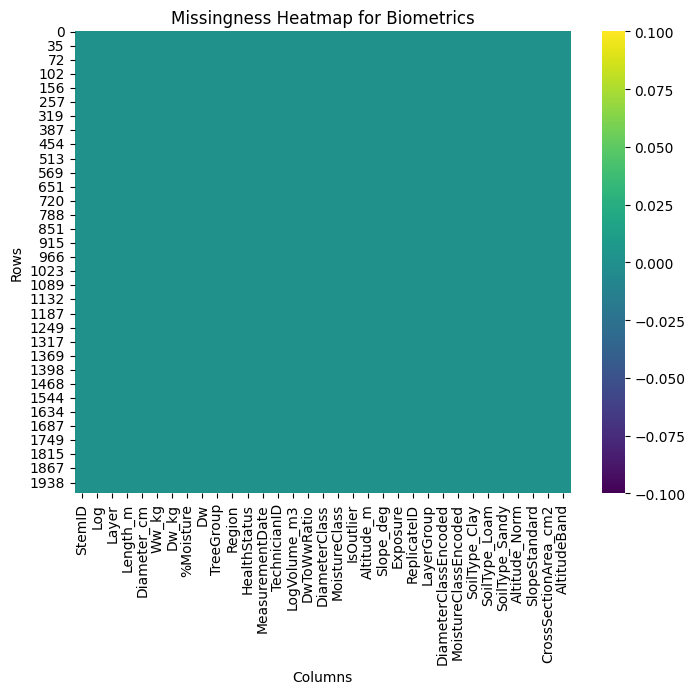

In [ ]:
#now checking if there is any missing data after data cleaning
plt.figure(figsize=(8, 6))
sns.heatmap(df.isna(),  cmap="viridis")
plt.title("Missingness Heatmap for Biometrics")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [ ]:
#Check for duplicates again but without having "Part" as a unique value as it is dropped now
UniqueKeys = ["StemID", "Layer","Log", "ReplicateID"]
DuplicateMask = df.duplicated(subset=UniqueKeys, keep="first")
print("duplicated rows number - ", DuplicateMask.sum())

duplicated rows number -  0


In [ ]:
#checking the main stats again, making sure everything is done
print(df.describe())

              Log    Length_m  Diameter_cm       Ww_kg       Dw_kg  \
count  492.000000  492.000000   492.000000  492.000000  492.000000   
mean     5.056911    3.448807    13.950025    0.795215    0.429357   
min      1.000000    0.000000     1.900000    0.006000    0.003000   
25%      2.000000    1.019961     7.126449    0.118207    0.057024   
50%      4.000000    2.700000    10.900436    0.369736    0.169042   
75%      7.000000    3.606151    18.025446    1.176559    0.603652   
max     15.000000   15.739264    51.338439    4.297103    2.739303   
std      3.679748    3.430337     9.833480    0.969022    0.555616   

        %Moisture          Dw                MeasurementDate  LogVolume_m3  \
count  492.000000  492.000000                            492    492.000000   
mean    54.529484    0.430191  2023-07-03 10:55:36.585365760      0.061766   
min     11.799856    0.003000            2023-01-02 00:00:00      0.000000   
25%     46.643780    0.056920            2023-04-06 00:00

In [ ]:
#check the shape of the dataset again
print("The shape of the dataset is ", df.shape)

The shape of the dataset is  (492, 33)
